In [386]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm, chi2_contingency

pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

In [387]:
orders = pd.read_csv('orders.csv', sep = ',')

orders.head(10)

,order_id,session_id,client_id,address_id,store_id,city,platform,order_created_at,order_date,delivery_slot_start,items_count,gross_merchandise_value,discount_type,discount_amount,delivery_fee,service_fee,paid_amount,payment_method,campaign_id,experiment_group,is_marketing_touched
0,O000000112,SESS000000651,C008041,A0011675,S031,Новосибирск,ios,2025-11-01 09:00:00,2025-11-01,2025-11-01 18:00:00,12,"2,620.76",none,0.00,0,39.31,"2,660.07",cash,NaN,no_campaign,0
1,O000000026,SESS000000148,C002410,A0002250,S067,Москва,ios,2025-11-01 09:18:00,2025-11-01,2025-11-01 11:00:00,7,"4,767.18",none,0.00,99,71.51,"4,937.69",card,NaN,no_campaign,0
2,O000000169,SESS000000872,C006795,A0006500,S011,Москва,ios,2025-11-01 09:19:11,2025-11-01,2025-11-01 19:00:00,18,"3,112.03",none,0.00,99,0.00,"3,211.03",card,NaN,no_campaign,0
3,O000000072,SESS000000433,C008460,A0010616,S057,Москва,web,2025-11-01 09:27:00,2025-11-01,2025-11-01 20:00:00,17,"3,380.14",none,0.00,99,50.70,"3,529.84",card,NaN,no_campaign,0
4,O000000008,SESS000000058,C008434,A0001936,S026,Екатеринбург,ios,2025-11-01 09:31:13,2025-11-01,2025-11-01 22:00:00,13,"3,501.61",fixed_amount,200.00,99,0.00,"3,400.61",card,NaN,no_campaign,0
5,O000000074,SESS000000440,C007510,A0012802,S071,Новосибирск,ios,2025-11-01 09:34:47,2025-11-01,2025-11-01 11:00:00,9,"3,328.87",none,0.00,149,66.58,"3,544.45",sbp,NaN,no_campaign,0
6,O000000019,SESS000000130,C007980,A0008525,S007,Санкт-Петербург,android,2025-11-01 09:43:19,2025-11-01,2025-11-01 22:00:00,13,"2,555.72",none,0.00,0,51.11,"2,606.83",card,NaN,no_campaign,0
7,O000000170,SESS000000874,C005427,A0000839,S024,Новосибирск,ios,2025-11-01 09:52:49,2025-11-01,2025-11-01 19:00:00,6,"2,392.20",none,0.00,199,47.84,"2,639.04",card,NaN,no_campaign,0
8,O000000178,SESS000000921,C006089,A0011244,S034,Санкт-Петербург,android,2025-11-01 09:57:24,2025-11-01,2025-11-01 12:00:00,6,"3,481.38",none,0.00,99,52.22,"3,632.60",card,NaN,no_campaign,0
9,O000000077,SESS000000455,C005227,A0011921,S068,Санкт-Петербург,web,2025-11-01 09:58:59,2025-11-01,2025-11-01 14:00:00,10,"1,687.31",none,0.00,149,25.31,"1,861.62",card,NaN,no_campaign,0


In [388]:
orders.describe()

,items_count,gross_merchandise_value,discount_amount,delivery_fee,service_fee,paid_amount,is_marketing_touched
count,"21,884.00","21,884.00","21,884.00","21,884.00","21,884.00","21,884.00","21,884.00"
mean,9.75,"2,822.22",49.20,104.75,35.94,"2,913.72",0.05
std,3.29,"1,049.98",108.65,66.52,26.61,"1,062.03",0.21
min,1.00,550.00,0.00,0.00,0.00,456.08,0.00
25%,7.00,"2,066.57",0.00,99.00,10.81,"2,144.27",0.00
50%,10.00,"2,683.22",0.00,99.00,37.77,"2,771.58",0.00
75%,12.00,"3,429.85",0.00,149.00,53.25,"3,534.02",0.00
max,26.00,"9,046.22",882.71,199.00,157.52,"9,195.22",1.00


In [389]:
orders.dtypes

order_id                       str
session_id                     str
client_id                      str
address_id                     str
store_id                       str
city                           str
platform                       str
order_created_at               str
order_date                     str
delivery_slot_start            str
items_count                  int64
gross_merchandise_value    float64
discount_type                  str
discount_amount            float64
delivery_fee                 int64
service_fee                float64
paid_amount                float64
payment_method                 str
campaign_id                    str
experiment_group               str
is_marketing_touched         int64
dtype: object

In [390]:
orders.isna().sum()

order_id                       0
session_id                     0
client_id                      0
address_id                     0
store_id                       0
city                           0
platform                       0
order_created_at               0
order_date                     0
delivery_slot_start            0
items_count                    0
gross_merchandise_value        0
discount_type                  0
discount_amount                0
delivery_fee                   0
service_fee                    0
paid_amount                    0
payment_method                 0
campaign_id                20838
experiment_group               0
is_marketing_touched           0
dtype: int64

In [391]:
session = pd.read_csv('client_session.csv', sep = ',')

session.head(15)

,session_id,client_id,address_id,session_start_at,session_date,city,platform,traffic_source,campaign_id,experiment_group,timing_period,service_visit,product_search,product_card_view,add_to_cart,cart_visit,purchase,order_id,search_at,product_card_view_at,add_to_cart_at,cart_visit_at,purchase_at
0,SESS000000514,C003975,A0000378,2025-11-01 08:04:53,2025-11-01,Москва,android,direct,NaN,no_campaign,no_campaign,1,1,1,0,0,0,NaN,2025-11-01 08:07:53,2025-11-01 08:07:53,NaN,NaN,NaN
1,SESS000000286,C000830,A0011473,2025-11-01 08:11:12,2025-11-01,Москва,android,organic,NaN,no_campaign,no_campaign,1,1,1,1,0,0,NaN,2025-11-01 08:12:12,2025-11-01 08:16:12,2025-11-01 08:23:12,NaN,NaN
2,SESS000000248,C005196,A0005849,2025-11-01 08:11:57,2025-11-01,Казань,ios,organic,NaN,no_campaign,no_campaign,1,1,1,1,1,0,NaN,2025-11-01 08:15:57,2025-11-01 08:21:57,2025-11-01 08:21:57,2025-11-01 08:31:57,NaN
3,SESS000000387,C007786,A0001717,2025-11-01 08:16:26,2025-11-01,Москва,android,direct,NaN,no_campaign,no_campaign,1,1,1,0,0,0,NaN,2025-11-01 08:18:26,2025-11-01 08:24:26,NaN,NaN,NaN
4,SESS000000197,C001541,A0001204,2025-11-01 08:21:22,2025-11-01,Санкт-Петербург,web,crm,CMP0001,test,evening,1,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5,SESS000000274,C005400,A0002967,2025-11-01 08:21:49,2025-11-01,Екатеринбург,ios,paid,NaN,no_campaign,no_campaign,1,1,1,0,0,0,NaN,2025-11-01 08:25:49,2025-11-01 08:24:49,NaN,NaN,NaN
6,SESS000000300,C000693,A0000678,2025-11-01 08:24:21,2025-11-01,Москва,web,crm,NaN,no_campaign,no_campaign,1,1,0,0,0,0,NaN,2025-11-01 08:29:21,NaN,NaN,NaN,NaN
7,SESS000000459,C006998,A0004857,2025-11-01 08:24:21,2025-11-01,Екатеринбург,ios,direct,NaN,no_campaign,no_campaign,1,1,1,0,0,0,NaN,2025-11-01 08:26:21,2025-11-01 08:34:21,NaN,NaN,NaN
8,SESS000000172,C005648,A0000249,2025-11-01 08:24:36,2025-11-01,Санкт-Петербург,ios,crm,NaN,no_campaign,no_campaign,1,1,0,0,0,0,NaN,2025-11-01 08:29:36,NaN,NaN,NaN,NaN
9,SESS000000054,C001175,A0001361,2025-11-01 08:25:18,2025-11-01,Санкт-Петербург,ios,paid,NaN,no_campaign,no_campaign,1,1,0,0,0,0,NaN,2025-11-01 08:26:18,NaN,NaN,NaN,NaN


In [392]:
session.describe()

,service_visit,product_search,product_card_view,add_to_cart,cart_visit,purchase
count,"144,710.00","144,710.00","144,710.00","144,710.00","144,710.00","144,710.00"
mean,1.00,0.72,0.60,0.31,0.24,0.15
std,0.00,0.45,0.49,0.46,0.43,0.36
min,1.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,0.00,0.00,0.00,0.00
50%,1.00,1.00,1.00,0.00,0.00,0.00
75%,1.00,1.00,1.00,1.00,0.00,0.00
max,1.00,1.00,1.00,1.00,1.00,1.00


In [393]:
session.dtypes

session_id                str
client_id                 str
address_id                str
session_start_at          str
session_date              str
city                      str
platform                  str
traffic_source            str
campaign_id               str
experiment_group          str
timing_period             str
service_visit           int64
product_search          int64
product_card_view       int64
add_to_cart             int64
cart_visit              int64
purchase                int64
order_id                  str
search_at                 str
product_card_view_at      str
add_to_cart_at            str
cart_visit_at             str
purchase_at               str
dtype: object

In [394]:
session.isna().sum()

session_id                   0
client_id                    0
address_id                   0
session_start_at             0
session_date                 0
city                         0
platform                     0
traffic_source               0
campaign_id             138011
experiment_group             0
timing_period                0
service_visit                0
product_search               0
product_card_view            0
add_to_cart                  0
cart_visit                   0
purchase                     0
order_id                122826
search_at                40586
product_card_view_at     57949
add_to_cart_at           99732
cart_visit_at           109487
purchase_at             122826
dtype: int64

In [395]:
marketing = pd.read_csv('marketing.csv', sep = ',')

marketing.head(15)

,communication_id,campaign_id,communication_type,client_id,send_datetime,send_date,send_hour,timing_period,experiment_group,send_status
0,COM00000001,CMP0001,email,C000437,2025-11-01 18:15:00,2025-11-01,18,evening,control,holdout_control
1,COM00000002,CMP0001,email,C004047,2025-11-01 18:15:00,2025-11-01,18,evening,control,holdout_control
2,COM00000003,CMP0001,email,C003127,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent
3,COM00000004,CMP0001,email,C005987,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent
4,COM00000005,CMP0001,email,C002831,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent
5,COM00000006,CMP0001,email,C001743,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent
6,COM00000007,CMP0001,email,C008201,2025-11-01 18:15:00,2025-11-01,18,evening,control,holdout_control
7,COM00000008,CMP0001,email,C007286,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent
8,COM00000009,CMP0001,email,C004196,2025-11-01 18:15:00,2025-11-01,18,evening,control,holdout_control
9,COM00000010,CMP0001,email,C002497,2025-11-01 18:15:00,2025-11-01,18,evening,control,holdout_control


In [396]:
marketing.dtypes

communication_id        str
campaign_id             str
communication_type      str
client_id               str
send_datetime           str
send_date               str
send_hour             int64
timing_period           str
experiment_group        str
send_status             str
dtype: object

In [397]:
marketing.isna().sum()

communication_id      0
campaign_id           0
communication_type    0
client_id             0
send_datetime         0
send_date             0
send_hour             0
timing_period         0
experiment_group      0
send_status           0
dtype: int64

In [398]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

orders["month"] = orders["order_date"].dt.to_period("M").astype(str)
orders["day_of_week"] = orders["order_date"].dt.day_name()
orders["day_type"] = np.where(
    orders["order_date"].dt.dayofweek.isin([5, 6]),
    "weekend",
    "weekday"
)
orders["order_created_at"] = pd.to_datetime(orders["order_created_at"])
orders["order_hour"] = orders["order_created_at"].dt.hour



session["session_date"] = pd.to_datetime(session["session_date"])

session["month"] = session["session_date"].dt.to_period("M").astype(str)
session["day_of_week"] = session["session_date"].dt.day_name()
session["day_type"] = np.where(
    session["session_date"].dt.dayofweek.isin([5, 6]),
    "weekend",
    "weekday"
)

session["session_start_at"] = pd.to_datetime(session["session_start_at"])
session["session_hour"] = session["session_start_at"].dt.hour


marketing["send_date"] = pd.to_datetime(marketing["send_date"])

marketing["month"] = marketing["send_date"].dt.to_period("M").astype(str)
marketing["day_of_week"] = marketing["send_date"].dt.day_name()
marketing["day_type"] = np.where(
    marketing["send_date"].dt.dayofweek.isin([5, 6]),
    "weekend",
    "weekday"
)

In [399]:
orders.head(5)

,order_id,session_id,client_id,address_id,store_id,city,platform,order_created_at,order_date,delivery_slot_start,items_count,gross_merchandise_value,discount_type,discount_amount,delivery_fee,service_fee,paid_amount,payment_method,campaign_id,experiment_group,is_marketing_touched,month,day_of_week,day_type,order_hour
0,O000000112,SESS000000651,C008041,A0011675,S031,Новосибирск,ios,2025-11-01 09:00:00,2025-11-01,2025-11-01 18:00:00,12,"2,620.76",none,0.00,0,39.31,"2,660.07",cash,NaN,no_campaign,0,2025-11,Saturday,weekend,9
1,O000000026,SESS000000148,C002410,A0002250,S067,Москва,ios,2025-11-01 09:18:00,2025-11-01,2025-11-01 11:00:00,7,"4,767.18",none,0.00,99,71.51,"4,937.69",card,NaN,no_campaign,0,2025-11,Saturday,weekend,9
2,O000000169,SESS000000872,C006795,A0006500,S011,Москва,ios,2025-11-01 09:19:11,2025-11-01,2025-11-01 19:00:00,18,"3,112.03",none,0.00,99,0.00,"3,211.03",card,NaN,no_campaign,0,2025-11,Saturday,weekend,9
3,O000000072,SESS000000433,C008460,A0010616,S057,Москва,web,2025-11-01 09:27:00,2025-11-01,2025-11-01 20:00:00,17,"3,380.14",none,0.00,99,50.70,"3,529.84",card,NaN,no_campaign,0,2025-11,Saturday,weekend,9
4,O000000008,SESS000000058,C008434,A0001936,S026,Екатеринбург,ios,2025-11-01 09:31:13,2025-11-01,2025-11-01 22:00:00,13,"3,501.61",fixed_amount,200.00,99,0.00,"3,400.61",card,NaN,no_campaign,0,2025-11,Saturday,weekend,9


In [400]:
session.head(5)

,session_id,client_id,address_id,session_start_at,session_date,city,platform,traffic_source,campaign_id,experiment_group,timing_period,service_visit,product_search,product_card_view,add_to_cart,cart_visit,purchase,order_id,search_at,product_card_view_at,add_to_cart_at,cart_visit_at,purchase_at,month,day_of_week,day_type,session_hour
0,SESS000000514,C003975,A0000378,2025-11-01 08:04:53,2025-11-01,Москва,android,direct,NaN,no_campaign,no_campaign,1,1,1,0,0,0,NaN,2025-11-01 08:07:53,2025-11-01 08:07:53,NaN,NaN,NaN,2025-11,Saturday,weekend,8
1,SESS000000286,C000830,A0011473,2025-11-01 08:11:12,2025-11-01,Москва,android,organic,NaN,no_campaign,no_campaign,1,1,1,1,0,0,NaN,2025-11-01 08:12:12,2025-11-01 08:16:12,2025-11-01 08:23:12,NaN,NaN,2025-11,Saturday,weekend,8
2,SESS000000248,C005196,A0005849,2025-11-01 08:11:57,2025-11-01,Казань,ios,organic,NaN,no_campaign,no_campaign,1,1,1,1,1,0,NaN,2025-11-01 08:15:57,2025-11-01 08:21:57,2025-11-01 08:21:57,2025-11-01 08:31:57,NaN,2025-11,Saturday,weekend,8
3,SESS000000387,C007786,A0001717,2025-11-01 08:16:26,2025-11-01,Москва,android,direct,NaN,no_campaign,no_campaign,1,1,1,0,0,0,NaN,2025-11-01 08:18:26,2025-11-01 08:24:26,NaN,NaN,NaN,2025-11,Saturday,weekend,8
4,SESS000000197,C001541,A0001204,2025-11-01 08:21:22,2025-11-01,Санкт-Петербург,web,crm,CMP0001,test,evening,1,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2025-11,Saturday,weekend,8


In [401]:
marketing.head(5)

,communication_id,campaign_id,communication_type,client_id,send_datetime,send_date,send_hour,timing_period,experiment_group,send_status,month,day_of_week,day_type
0,COM00000001,CMP0001,email,C000437,2025-11-01 18:15:00,2025-11-01,18,evening,control,holdout_control,2025-11,Saturday,weekend
1,COM00000002,CMP0001,email,C004047,2025-11-01 18:15:00,2025-11-01,18,evening,control,holdout_control,2025-11,Saturday,weekend
2,COM00000003,CMP0001,email,C003127,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent,2025-11,Saturday,weekend
3,COM00000004,CMP0001,email,C005987,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent,2025-11,Saturday,weekend
4,COM00000005,CMP0001,email,C002831,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent,2025-11,Saturday,weekend


## Гипотезы где может находиться проблема
Произошло снижение оборота в последнем месяце. 
Оборот сервиса - это составная метрика:

> **Оборот = количество успешных заказов * средний чек**

>**Средний чек = Количество товаров в заказе * средняя цена одного товара**

>**Количество заказов = количество покупателей * частота**

>**Количество покупателей = сколько людей зашло в приложение(MAU) * конверсия**

**Срезы**

* Платформа
* Город
* Конкретный магазин
* Способ оплаты
* Тип клиента (новый/вернувшийся/лояльный)
* День недели
* Время отправки коммуникации
* Источник трафика
* Маркетинговая кампания
* Канал коммуникации
* Экспериментальная группа(тест, контроль)

Перед анализом я сформулировала основные вопросы, которые помогут понять причину падения :

**1. Проблемы c количеством покупок и со средним чеком и скидками**
- Пользователи начали делать меньше покупок?
- Снизился ли средний чек? 
- Было больше скидок в апреле?
- Может быть проблема произошла в конкретном городе, а не во всех?

**2. Проблемы с Трафиком**
- Отключился или сломался конкретный рекламный канал?
- Сломались маркетинговые рассылки / пуши (пользователи перестали получать напоминания)?
- Снизился трафик на конкретной платформе?

**3. Проблемы с Конверсией**
- Произошел технический сбой на конкретном шаге воронки (поиск -> карточка -> корзина -> оплата)?
- Появился баг в приложении на конкретной платформе?
- Отвалился конкретный способ оплаты?

**4. Продуктовые эксперименты и Условия сервиса**
- Был запущен неудачный A/B тест, который ухудшил метрики в тестовой группе?
- Сильно выросла стоимость доставки или сервисный сбор, что отпугнуло клиентов?



## Таблица заказы

## Ключевые метрики заказов

Первый месяц в данных принимается за 100%, чтобы посмотреть относительную динамику каждой метрики.

Сравниваются основные показатели из таблицы заказов:

* выручка
* GMV
* количество заказов
* средний чек
* средняя скидка
* количество активных покупателей
* частота покупок 

Это помогает понять, за счёт какого фактора изменился оборот: количества заказов, среднего чека, активности покупателей или частоты покупок.


In [402]:
orders_metrics = orders.groupby('month').agg(
    revenue=('paid_amount', 'sum'),
    gmv=('gross_merchandise_value', 'sum'),
    num_orders=('order_id', 'nunique'),
    avg_order_val=('paid_amount', 'mean'),
    avg_discount=('discount_amount', 'mean'),
    num_buyers=('client_id', 'nunique')
).reset_index()
orders_metrics['frequency'] = orders_metrics['num_orders'] / orders_metrics['num_buyers']
orders_metrics 

,month,revenue,gmv,num_orders,avg_order_val,avg_discount,num_buyers,frequency
0,2025-11,"10,693,902.34","10,353,931.61",3659,"2,922.63",48.84,2812,1.30
1,2025-12,"11,573,313.28","11,213,674.63",3942,"2,935.90",49.63,2959,1.33
2,2026-01,"10,874,341.65","10,532,168.55",3719,"2,924.00",48.19,2871,1.30
3,2026-02,"10,250,867.63","9,926,552.57",3491,"2,936.37",47.19,2707,1.29
4,2026-03,"11,573,997.82","11,228,694.03",3955,"2,926.42",54.14,2996,1.32
5,2026-04,"8,797,446.90","8,506,511.12",3118,"2,821.50",46.23,2525,1.23


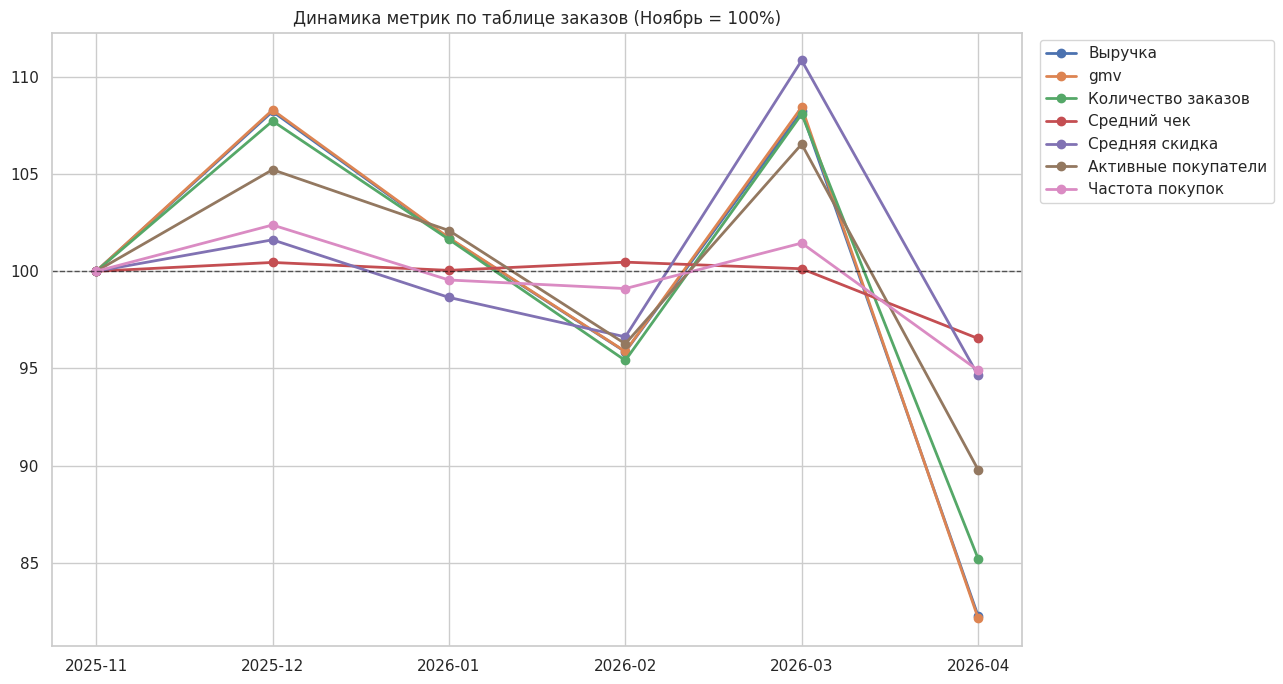

In [403]:
plt.figure(figsize=(13, 7))

metrics_map = {
    "revenue": "Выручка",
    "gmv": "gmv",
    "num_orders": "Количество заказов",
    "avg_order_val": "Средний чек",
    "avg_discount": "Средняя скидка",
    "num_buyers": "Активные покупатели",
    "frequency": "Частота покупок"
}

orders_metrics = orders_metrics.copy()
orders_metrics = orders_metrics.sort_values("month").reset_index(drop=True)

base_month = orders_metrics["month"].iloc[0]

for col in metrics_map.keys():
    base_value = orders_metrics[col].iloc[0]
    orders_metrics[col] = orders_metrics[col] / base_value * 100


for col, label in metrics_map.items():
    plt.plot(
        orders_metrics["month"],
        orders_metrics[col],
        marker="o",
        linewidth=2,
        label=label
    )


plt.title(
    f"Динамика метрик по таблице заказов (Ноябрь = 100%)",
    fontsize=12
)
plt.axhline(100, color="black", linestyle="--", linewidth=1, alpha=0.6)
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

### Вывод по динамике метрик заказов

Выручка и GMV снизились сильнее остальных показателей - примерно до 82% от уровня ноября.

При этом средний чек снизился примерно до 96%. Это значит, что пользователи не стали покупать более дешевые товары или делать меньшие по стоимости заказы.

Основное снижение связано с количеством заказов и активностью покупателей:

* количество заказов упало примерно до 85% от уровня ноября;
* количество активных покупателей снизилось примерно до 90%;
* частота покупок также немного просела - примерно до 95%.

**Промежуточный вывод:** оборот снизился не из-за того, что пользователи стали меньше платить за один заказ. Основная причина падения - потеря части активных покупателей и снижение количества заказов.


## Анализ количества заказов по сегментам

Проверим следующие разрезы:

* платформа
* группа эксперимента
* способ оплаты
* город
* топ-10 магазинов
* маркетинговые и органические заказы

Цель этого блока - определить, является ли падение заказов общей проблемой по всему сервису или оно сосредоточено в отдельных сегментах.


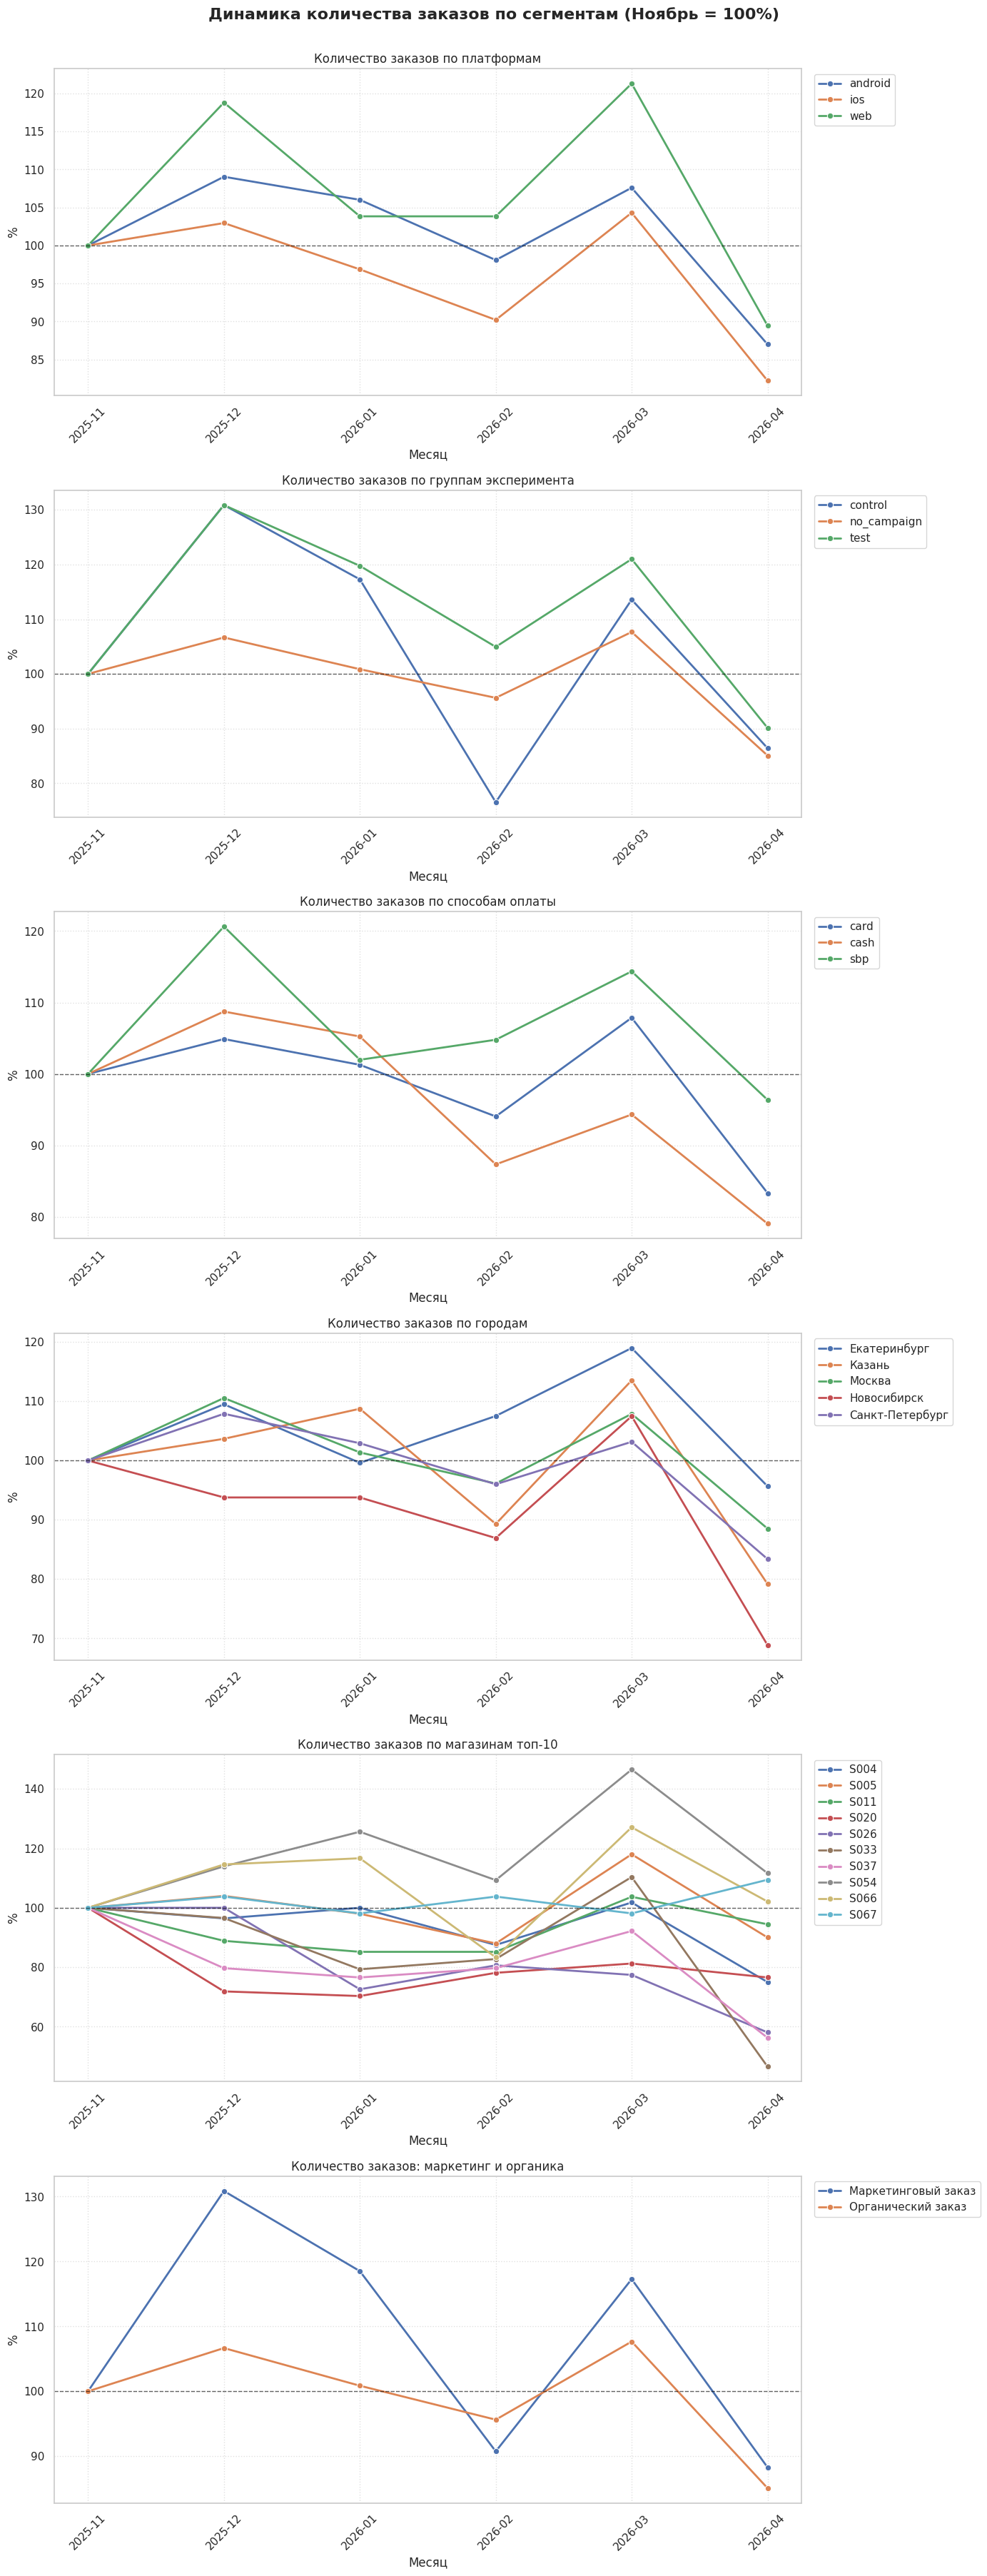

In [404]:
orders_segment = orders.sort_values("month").copy()

def make_index_data(df, segment_col):
    data = (
        df
        .groupby(["month", segment_col], observed=False)["order_id"]
        .nunique()
        .reset_index(name="num_orders")
        .sort_values("month")
    )

    data["indexed_orders"] = (
        data
        .groupby(segment_col, observed=False)["num_orders"]
        .transform(lambda x: x / x.iloc[0] * 100 if x.iloc[0] != 0 else np.nan)
    )

    return data


fig, axes = plt.subplots(6, 1, figsize=(14, 36))


platform_data = make_index_data(orders_segment, "platform")

sns.lineplot(
    data=platform_data,
    x="month",
    y="indexed_orders",
    hue="platform",
    marker="o",
    linewidth=2,
    ax=axes[0]
)

axes[0].set_title("Количество заказов по платформам", fontsize=12)


exp_data = make_index_data(orders_segment, "experiment_group")

sns.lineplot(
    data=exp_data,
    x="month",
    y="indexed_orders",
    hue="experiment_group",
    marker="o",
    linewidth=2,
    ax=axes[1]
)

axes[1].set_title("Количество заказов по группам эксперимента", fontsize=12)


payment_data = make_index_data(orders_segment, "payment_method")

sns.lineplot(
    data=payment_data,
    x="month",
    y="indexed_orders",
    hue="payment_method",
    marker="o",
    linewidth=2,
    ax=axes[2]
)

axes[2].set_title("Количество заказов по способам оплаты", fontsize=12)


city_data = make_index_data(orders_segment, "city")

sns.lineplot(
    data=city_data,
    x="month",
    y="indexed_orders",
    hue="city",
    marker="o",
    linewidth=2,
    ax=axes[3]
)

axes[3].set_title("Количество заказов по городам", fontsize=12)

top_stores = orders_segment["store_id"].value_counts().head(10).index
store_orders = orders_segment[orders_segment["store_id"].isin(top_stores)].copy()
store_orders["store_id"] = store_orders["store_id"].astype(str)

store_data = make_index_data(store_orders, "store_id")

sns.lineplot(
    data=store_data,
    x="month",
    y="indexed_orders",
    hue="store_id",
    marker="o",
    linewidth=2,
    ax=axes[4]
)

axes[4].set_title("Количество заказов по магазинам топ-10", fontsize=12)


orders_segment["marketing_type"] = np.where(
    orders_segment["is_marketing_touched"].isin([1, 1.0, "1", True]),
    "Маркетинговый заказ",
    "Органический заказ"
)

marketing_data = make_index_data(orders_segment, "marketing_type")

sns.lineplot(
    data=marketing_data,
    x="month",
    y="indexed_orders",
    hue="marketing_type",
    marker="o",
    linewidth=2,
    ax=axes[5]
)

axes[5].set_title("Количество заказов: маркетинг и органика", fontsize=12)


for ax in axes:
    ax.set_xlabel("Месяц")
    ax.set_ylabel("%")
    ax.axhline(100, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))

plt.suptitle(
    f"Динамика количества заказов по сегментам (Ноябрь = 100%)",
    fontsize=16,
    fontweight="bold",
    y=1.002
)

plt.tight_layout()
plt.show()

### Вывод по сегментному анализу заказов

По платформам снижение произошло на всех каналах: `android`, `ios` и `web`. Сильнее всего просел `ios`, но остальные платформы также ушли ниже уровня ноября.

По группам эксперимента также видно общее снижение в апреле. Падение есть и в `control`, и в `test`, и в группе без кампании

По способам оплаты снижение тоже присутствует во всех группах. Наиболее заметно просели заказы с оплатой `cash` и `card`.

По городам падение есть во всех городах, но выражено неравномерно. Сильнее всего падение было в Новосибирске, также заметное снижение есть в Казани и Санкт-Петербурге.

Часть магазинов просела значительно сильнее остальных, но почти у всех наблюдается спад.

Маркетинговые и органические заказы в апреле снизились одновременно. Падение нельзя объяснить только ухудшением маркетинга. Проблема затронула общий спрос или продуктовую воронку.

**Промежуточный вывод:** падение заказов в апреле носит системный характер, так как оно наблюдается почти во всех сегментах.

## Проверка дополнительных факторов: скидки, дни недели, время суток

Может быть падение оборота связано с изменением условий заказа: стоимостью доставки, сервисным сбором, размером корзины или скидками.

Также отдельно посмотрим динамику заказов в будни и выходные. Это важно, потому что падение может быть связано с изменением поведения пользователей в определённые дни недели.


In [405]:
orders_analysis = orders.copy()

fees_analysis = (
    orders_analysis
    .groupby("month", as_index=False, observed=False)
    .agg(
        avg_delivery_fee=("delivery_fee", "mean"),
        avg_service_fee=("service_fee", "mean"),
        avg_items_count=("items_count", "mean")
    )
)

display(fees_analysis)


discount_matrix = (
    orders_analysis
    .groupby(["month", "discount_type"], observed=False)
    .size()
    .unstack(fill_value=0)
)

display(discount_matrix)

day_type_orders = (
    orders_analysis
    .groupby(["month", "day_type"], observed=False)["order_id"]
    .nunique()
    .unstack(fill_value=0)
)

day_type_indexed = day_type_orders.div(day_type_orders.iloc[0]) * 100

display(day_type_indexed.round(2))

,month,avg_delivery_fee,avg_service_fee,avg_items_count
0,2025-11,105.20,36.56,9.81
1,2025-12,104.75,36.12,9.75
2,2026-01,103.70,36.50,9.68
3,2026-02,104.18,35.92,9.72
4,2026-03,105.69,35.76,9.75
5,2026-04,104.95,34.58,9.83


discount_type,fixed_amount,free_delivery,none,percent
month,,,,
2025-11,377,124,2767,391
2025-12,408,171,2941,422
2026-01,362,174,2763,420
2026-02,325,142,2662,362
2026-03,420,184,2855,496
2026-04,283,124,2350,361


day_type,weekday,weekend
month,,
2025-11,100.00,100.00
2025-12,123.33,82.19
2026-01,111.44,85.58
2026-02,106.43,77.36
2026-03,116.33,94.59
2026-04,96.30,67.05


### Вывод
Средняя доставка держится около 104–106, сервисный сбор находится примерно в диапазоне 35–37, а среднее количество товаров в корзине - около 9.7–9.8. Это значит, что падение оборота вряд ли связано с резким ростом сборов или уменьшением корзины.

В апреле снизилось количество заказов почти по всем типам скидок, но это скорее следствие общего падения заказов, а не отдельная причина.

Заказы в будни в апреле снизились до 96% от уровня ноября, а заказы в выходные до 67%. То есть выходные просели значительно сильнее.

**Промежуточный вывод:** стоимость доставки, сервисный сбор, размер корзины и скидки не выглядят основной причиной падения оборота. Более важный фактор - сильное снижение заказов в выходные дни.Возможно, выходных в апреле было меньше или изменилась маркетинговая активность, доступность магазинов, ассортимент, доставка или пользовательский спрос именно в выходные.


### Количество будних и выходных дней по месяцам


In [406]:
day_type_orders = (
    orders
    .groupby(["month", "day_type"], observed=False)["order_id"]
    .nunique()
    .unstack(fill_value=0)
)

month_list = sorted(orders["month"].unique())

days_in_month = []

for month in month_list:
    period = pd.Period(month, freq="M")
    dates = pd.date_range(period.start_time, period.end_time, freq="D")
    
    days_in_month.append({
        "month": month,
        "weekday_days": (~dates.dayofweek.isin([5, 6])).sum(),
        "weekend_days": dates.dayofweek.isin([5, 6]).sum()
    })

days_in_month = pd.DataFrame(days_in_month).set_index("month")

display(days_in_month)

,weekday_days,weekend_days
month,,
2025-11,20,10
2025-12,23,8
2026-01,22,9
2026-02,20,8
2026-03,22,9
2026-04,22,8


### Cреднее количество заказов в будний день и в выходной

In [407]:
orders_per_day = day_type_orders.copy()

orders_per_day["weekday"] = orders_per_day["weekday"] / days_in_month["weekday_days"]
orders_per_day["weekend"] = orders_per_day["weekend"] / days_in_month["weekend_days"]

display(orders_per_day.round(2).reset_index())

day_type,month,weekday,weekend
0,2025-11,113.60,138.70
1,2025-12,121.83,142.50
2,2026-01,115.09,131.89
3,2026-02,120.90,134.12
4,2026-03,120.14,145.78
5,2026-04,99.45,116.25


## Динамика заказов будни и выходные

Ноябрь принимается за 100%, а следующие месяцы показывают, как менялось среднее количество заказов на один день относительно ноября.


In [408]:
orders_per_day_indexed = (
    orders_per_day
    .div(orders_per_day.iloc[0])
    * 100
)

display(orders_per_day_indexed.round(2).reset_index())

day_type,month,weekday,weekend
0,2025-11,100.00,100.00
1,2025-12,107.24,102.74
2,2026-01,101.31,95.09
3,2026-02,106.43,96.70
4,2026-03,105.75,105.10
5,2026-04,87.55,83.81


### Вывод по динамике заказов в будни и выходные

После пересчёта на среднее количество заказов в день видно, что в апреле просели и будни, и выходные.
Относительно ноября будни в апреле снизились до 87.55%, а выходные до 83.81%.

Это значит, что падение заказов не объясняется только количеством будних или выходных дней в месяце.

**Промежуточный вывод:** в апреле снизилась активность пользователей как в будни, так и в выходные.


## Анализ заказов по времени суток

Дополнительно проверим, изменилось ли распределение заказов по времени суток. Это нужно, чтобы понять, не связано ли падение оборота с просадкой в конкретный период дня: утром, днём, вечером или ночью.

Сначала смотрим долю каждого интервала внутри месяца, затем индекс количества заказов относительно ноября.


time_of_day,Ночь 00-06,Утро 06-12,День 12-18,Вечер 18-24
month,,,,
2025-11,1.26,13.66,41.51,43.56
2025-12,1.37,13.93,42.01,42.69
2026-01,1.32,13.55,41.14,43.99
2026-02,1.17,13.46,42.05,43.31
2026-03,1.29,13.38,41.97,43.36
2026-04,1.28,14.75,40.73,43.23


time_of_day,Ночь 00-06,Утро 06-12,День 12-18,Вечер 18-24
month,,,,
2025-11,100.00,100.00,100.00,100.00
2025-12,117.39,109.80,109.02,105.58
2026-01,106.52,100.80,100.72,102.63
2026-02,89.13,94.00,96.64,94.86
2026-03,110.87,105.80,109.28,107.59
2026-04,86.96,92.00,83.61,84.57


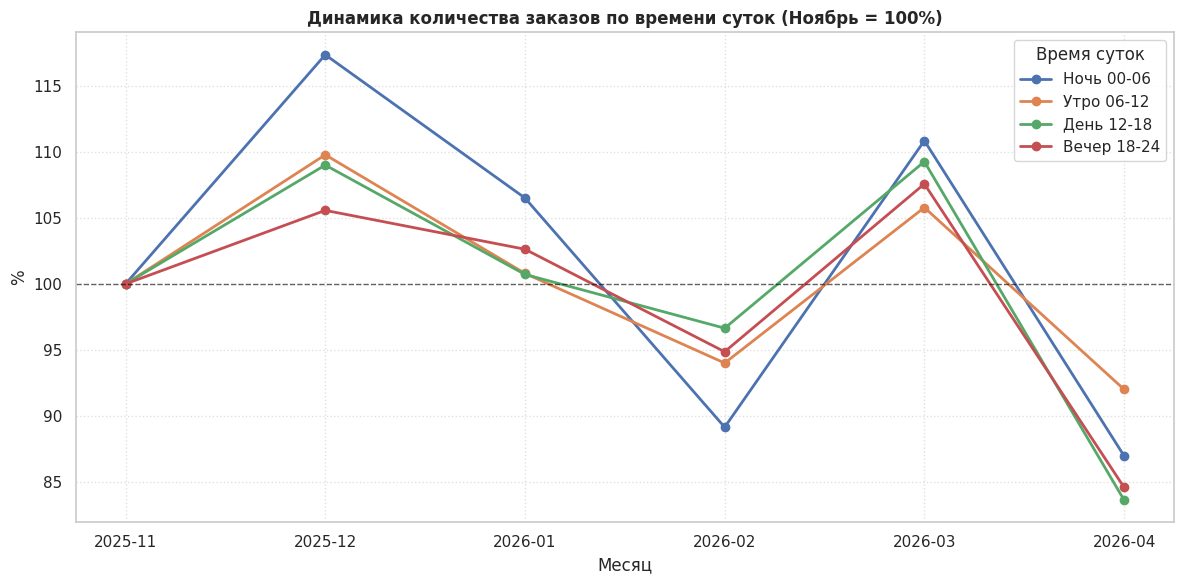

In [409]:
orders_time = orders.copy()

orders_time["time_of_day"] = pd.cut(
    orders_time["order_hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=[
        "Ночь 00-06",
        "Утро 06-12",
        "День 12-18",
        "Вечер 18-24"
    ]
)

time_of_day_orders = (
    orders_time
    .groupby(["month", "time_of_day"], observed=False)["order_id"]
    .nunique()
    .unstack(fill_value=0)
)

time_of_day_shares = (
    time_of_day_orders
    .div(time_of_day_orders.sum(axis=1), axis=0)
    * 100
)

time_of_day_indexed = (
    time_of_day_orders
    .div(time_of_day_orders.iloc[0])
    * 100
)

display(time_of_day_shares.round(2))
display(time_of_day_indexed.round(2))


plt.figure(figsize=(12, 6))

for col in time_of_day_indexed.columns:
    plt.plot(
        time_of_day_indexed.index,
        time_of_day_indexed[col],
        marker="o",
        linewidth=2,
        label=col
    )

base_month = time_of_day_indexed.index[0]

plt.title(
    f"Динамика количества заказов по времени суток (Ноябрь = 100%)",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Месяц")
plt.ylabel("%")
plt.axhline(100, color="black", linestyle="--", linewidth=1, alpha=0.6)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(title="Время суток")

plt.tight_layout()
plt.show()

### Вывод по заказам по времени суток

Основная часть заказов приходится на день и вечер: днём около 41–42%, вечером около 43–44% всех заказов. Утро занимает примерно 13–15%, ночь около 1%.

Структура поведения пользователей по времени суток заметно не изменилась. Пользователи не начали массово заказывать в другое время дня.

При этом количество заказов в апреле снизилось во всех временных интервалах:

* ночь - примерно до 87%
* утро - примерно до 92%
* день - примерно до 84%
* вечер - примерно до 85%

Наиболее заметная просадка наблюдается в дневных и вечерних заказах. Это важно, потому что именно на день и вечер приходится основная доля заказов.

**Промежуточный вывод:** падение заказов не связано с резким изменением времени покупок. Проблема выглядит как общее снижение количества заказов во всех частях дня, сильнее всего затронувшее дневной и вечерний периоды.


## Анализ пользовательской воронки

Проверяем на каком этапе пользовательского пути могла возникнуть проблема. Для этого посмотрим воронку от визита в сервис до покупки.

Воронка состоит из следующих шагов:

1. визит в сервис
2. поиск товара
3. просмотр карточки товара
4. добавление товара в корзину
5. переход в корзину
6. покупка

Сначала посмотрим абсолютное количество пользователей на каждом шаге по месяцам, затем рассчитаем конверсии между соседними шагами и общую конверсию из визита в покупку.


In [410]:
funnel_monthly = (
    session
    .groupby("month", as_index=False, observed=False)
    .agg(
        visits=("service_visit", "sum"),
        search=("product_search", "sum"),
        card_view=("product_card_view", "sum"),
        add_to_cart=("add_to_cart", "sum"),
        cart_visit=("cart_visit", "sum"),
        purchase=("purchase", "sum")
    )
)

funnel_monthly["CR1_visit_to_search"] = (
    funnel_monthly["search"] / funnel_monthly["visits"] * 100
).round(2)

funnel_monthly["CR2_search_to_view"] = (
    funnel_monthly["card_view"] / funnel_monthly["search"] * 100
).round(2)

funnel_monthly["CR3_view_to_cart"] = (
    funnel_monthly["add_to_cart"] / funnel_monthly["card_view"] * 100
).round(2)

funnel_monthly["CR4_cart_to_checkout"] = (
    funnel_monthly["cart_visit"] / funnel_monthly["add_to_cart"] * 100
).round(2)

funnel_monthly["CR5_checkout_to_purchase"] = (
    funnel_monthly["purchase"] / funnel_monthly["cart_visit"] * 100
).round(2)

funnel_monthly["Total_CR"] = (
    funnel_monthly["purchase"] / funnel_monthly["visits"] * 100
).round(2)

display(
    funnel_monthly[
        [
            "month",
            "visits",
            "search",
            "card_view",
            "add_to_cart",
            "cart_visit",
            "purchase"
        ]
    ]
)

display(
    funnel_monthly[
        [
            "month",
            "CR1_visit_to_search",
            "CR2_search_to_view",
            "CR3_view_to_cart",
            "CR4_cart_to_checkout",
            "CR5_checkout_to_purchase",
            "Total_CR"
        ]
    ]
)

,month,visits,search,card_view,add_to_cart,cart_visit,purchase
0,2025-11,23910,17186,14273,7607,5942,3659
1,2025-12,25678,18504,15466,8122,6325,3942
2,2026-01,24135,17462,14569,7630,6012,3719
3,2026-02,22740,16347,13666,7243,5647,3491
4,2026-03,25014,18021,14972,7916,6249,3955
5,2026-04,23233,16604,13815,6460,5048,3118


,month,CR1_visit_to_search,CR2_search_to_view,CR3_view_to_cart,CR4_cart_to_checkout,CR5_checkout_to_purchase,Total_CR
0,2025-11,71.88,83.05,53.30,78.11,61.58,15.30
1,2025-12,72.06,83.58,52.52,77.87,62.32,15.35
2,2026-01,72.35,83.43,52.37,78.79,61.86,15.41
3,2026-02,71.89,83.60,53.00,77.96,61.82,15.35
4,2026-03,72.04,83.08,52.87,78.94,63.29,15.81
5,2026-04,71.47,83.20,46.76,78.14,61.77,13.42


### Вывод по пользовательской воронке

В апреле видно снижение почти на всех шагах воронки.

Общая конверсия из визита в покупку также заметно снизилась: с 15.81% в марте до 13.42% в апреле. Это означает, что проблема не только в количестве пользователей, но и в том, что пользователи хуже доходят до покупки.

Самое сильное изменение видно на шаге из просмотра карточки товара в добавление в корзину. Конверсия упала с 52.87% до 46.76%. Остальные шаги воронки остались относительно стабильными: поиск, просмотр карточки, переход в корзину и финальная покупка.

**Промежуточный вывод:** ключевая проблема находится на этапе карточки товара. Пользователи доходят до карточек, но заметно хуже добавляют товары в корзину.


## Проверка сквозной конверсии по платформам и экспериментальным группам


Для этого сравним CR в двух сегментах:

* по платформам
* по экспериментальным группам

Если падение есть только в одной платформе или группе, проблема может быть локальной: баг, неудачный эксперимент или изменение пользовательского опыта в конкретном сегменте.


In [411]:
def calculate_cr_by_segment(df, segment_col):
    cr_data = (
        df
        .groupby(["month", segment_col], as_index=False, observed=False)
        .agg(
            visits=("service_visit", "sum"),
            purchases=("purchase", "sum")
        )
    )

    cr_data["CR"] = (
        cr_data["purchases"] / cr_data["visits"] * 100
    ).round(2)

    cr_pivot = (
        cr_data
        .pivot(index="month", columns=segment_col, values="CR")
    )

    return cr_pivot

platform_cr_pivot = calculate_cr_by_segment(session, "platform")
display(platform_cr_pivot)


exp_cr_pivot = calculate_cr_by_segment(session, "experiment_group")
display(exp_cr_pivot)

platform,android,ios,web
month,,,
2025-11,15.00,15.82,14.68
2025-12,15.10,15.35,16.07
2026-01,15.75,15.18,15.11
2026-02,15.15,15.30,16.10
2026-03,15.42,15.87,16.73
2026-04,13.36,13.59,13.14


experiment_group,control,no_campaign,test
month,,,
2025-11,14.59,15.29,16.88
2025-12,16.61,15.26,17.73
2026-01,16.61,15.34,17.20
2026-02,13.72,15.34,17.35
2026-03,14.77,15.87,14.71
2026-04,13.36,13.42,13.59


### Вывод по сквозной конверсии

В апреле сквозная конверсия снизилась на всех платформах:

* `android`: с 15.42% до 13.36%
* `ios`: с 15.87% до 13.59%
* `web`: с 16.73% до 13.14%.
 Просадка затронула весь сервис.

По экспериментальным группам картина похожая. В апреле конверсия снизилась во всех группах:

* `control`: с 14.77% до 13.36%
* `no_campaign`: с 15.87% до 13.42%
* `test`: с 14.71% до 13.59%.

Значит, падение нельзя объяснить только неудачным A/B-тестом или одной экспериментальной группой.

**Промежуточный вывод:** снижение конверсии наблюдается и на всех платформах и во всех экспериментальных группах.


## Пошаговая конверсия по платформам и экспериментальным группам

Посмотрим пошаговую конверсию:

* по платформам
* по экспериментальным группам

In [412]:
plat_steps = (
    session
    .groupby(["month", "platform"], as_index=False, observed=False)
    .agg(
        visits=("service_visit", "sum"),
        search=("product_search", "sum"),
        card_view=("product_card_view", "sum"),
        add_to_cart=("add_to_cart", "sum"),
        cart_visit=("cart_visit", "sum"),
        purchase=("purchase", "sum")
    )
)

plat_steps["CR1_visit_to_search"] = (
    plat_steps["search"] / plat_steps["visits"] * 100
).round(2)

plat_steps["CR2_search_to_view"] = (
    plat_steps["card_view"] / plat_steps["search"] * 100
).round(2)

plat_steps["CR3_view_to_cart"] = (
    plat_steps["add_to_cart"] / plat_steps["card_view"] * 100
).round(2)

plat_steps["CR4_cart_to_checkout"] = (
    plat_steps["cart_visit"] / plat_steps["add_to_cart"] * 100
).round(2)

plat_steps["CR5_checkout_to_purchase"] = (
    plat_steps["purchase"] / plat_steps["cart_visit"] * 100
).round(2)

plat_conversion_table = plat_steps[
    [
        "platform",
        "month",
        "CR1_visit_to_search",
        "CR2_search_to_view",
        "CR3_view_to_cart",
        "CR4_cart_to_checkout",
        "CR5_checkout_to_purchase"
    ]
].sort_values(["platform", "month"]).reset_index(drop=True)

display(plat_conversion_table)

,platform,month,CR1_visit_to_search,CR2_search_to_view,CR3_view_to_cart,CR4_cart_to_checkout,CR5_checkout_to_purchase
0,android,2025-11,71.52,82.62,53.33,77.81,61.17
1,android,2025-12,71.83,83.80,52.17,77.45,62.09
2,android,2026-01,71.81,83.86,53.15,78.84,62.43
3,android,2026-02,72.07,84.07,52.94,78.05,60.51
4,android,2026-03,71.62,83.16,52.17,79.10,62.73
5,android,2026-04,71.78,83.48,46.74,77.26,61.72
6,ios,2025-11,72.31,83.77,53.07,79.00,62.29
7,ios,2025-12,72.27,83.45,52.44,78.15,62.09
8,ios,2026-01,72.79,82.83,52.07,78.76,61.37
9,ios,2026-02,71.77,82.88,53.31,78.10,61.76


In [413]:
exp_steps = (
    session
    .groupby(["month", "experiment_group"], as_index=False, observed=False)
    .agg(
        visits=("service_visit", "sum"),
        search=("product_search", "sum"),
        card_view=("product_card_view", "sum"),
        add_to_cart=("add_to_cart", "sum"),
        cart_visit=("cart_visit", "sum"),
        purchase=("purchase", "sum")
    )
)

exp_steps["CR1_visit_to_search"] = (
    exp_steps["search"] / exp_steps["visits"] * 100
).round(2)

exp_steps["CR2_search_to_view"] = (
    exp_steps["card_view"] / exp_steps["search"] * 100
).round(2)

exp_steps["CR3_view_to_cart"] = (
    exp_steps["add_to_cart"] / exp_steps["card_view"] * 100
).round(2)

exp_steps["CR4_cart_to_checkout"] = (
    exp_steps["cart_visit"] / exp_steps["add_to_cart"] * 100
).round(2)

exp_steps["CR5_checkout_to_purchase"] = (
    exp_steps["purchase"] / exp_steps["cart_visit"] * 100
).round(2)

exp_conversion_table = exp_steps[
    [
        "experiment_group",
        "month",
        "CR1_visit_to_search",
        "CR2_search_to_view",
        "CR3_view_to_cart",
        "CR4_cart_to_checkout",
        "CR5_checkout_to_purchase"
    ]
].sort_values(["experiment_group", "month"]).reset_index(drop=True)

display(exp_conversion_table)

,experiment_group,month,CR1_visit_to_search,CR2_search_to_view,CR3_view_to_cart,CR4_cart_to_checkout,CR5_checkout_to_purchase
0,control,2025-11,71.53,84.89,53.71,77.90,57.45
1,control,2025-12,72.57,82.51,52.88,82.67,63.47
2,control,2026-01,73.60,85.04,52.51,84.57,59.75
3,control,2026-02,73.23,84.29,47.67,78.20,59.62
4,control,2026-03,72.07,83.52,49.07,77.72,64.34
5,control,2026-04,72.33,83.38,46.20,78.08,61.40
6,no_campaign,2025-11,71.82,83.03,53.01,78.22,61.83
7,no_campaign,2025-12,72.13,83.65,52.25,77.69,62.31
8,no_campaign,2026-01,72.25,83.44,52.17,78.68,61.96
9,no_campaign,2026-02,71.95,83.59,52.89,77.96,61.86


### Вывод по пошаговой конверсии в сегментах

По платформам видно, что в апреле просел именно шаг `CR3_view_to_cart`:

* `android`: с 52.17% в марте до 46.74% в апреле
* `ios`: с 53.32% до 47.11%
* `web`: с 53.56% до 45.85%.

Конверсия из визита в поиск, из поиска в карточку, из корзины в оформление и из оформления в покупку не показывают такого сильного падения.

По экспериментальным группам ситуация похожая. В апреле `CR3_view_to_cart` снизился во всех группах:

* `control`: с 49.07% до 46.20%
* `no_campaign`: с 52.85% до 46.73%
* `test`: с 57.48% до 48.41%.

Самая сильная просадка заметна в группе test, но падение есть не только там. Поэтому проблему нельзя объяснить только экспериментом.

**Промежуточный вывод:** Пользователи в апреле хуже добавляют товары в корзину. Нужно проверять карточки товаров, наличие товаров, цены, ассортимент, кнопку добавления в корзину и возможные изменения интерфейса.


## Пошаговая конверсия по времени суток

Разобьём сессии на интервалы:

* ночь: 00:00–06:00
* утро: 06:00–12:00
* день: 12:00–18:00
* вечер: 18:00–24:00

Будет понятно просела ли конверсия только в определённый период дня или проблема проявляется во всех основных временных интервалах.


In [414]:
session["session_time_of_day"] = pd.cut(
    session["session_hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=[
        "Ночь 00-06",
        "Утро 06-12",
        "День 12-18",
        "Вечер 18-24"
    ]
)

time_steps = (
    session
    .groupby(["month", "session_time_of_day"], as_index=False, observed=False)
    .agg(
        visits=("service_visit", "sum"),
        search=("product_search", "sum"),
        card_view=("product_card_view", "sum"),
        add_to_cart=("add_to_cart", "sum"),
        cart_visit=("cart_visit", "sum"),
        purchase=("purchase", "sum")
    )
)

time_steps["CR1_visit_to_search"] = (
    time_steps["search"] / time_steps["visits"] * 100
).round(2)

time_steps["CR2_search_to_view"] = (
    time_steps["card_view"] / time_steps["search"] * 100
).round(2)

time_steps["CR3_view_to_cart"] = (
    time_steps["add_to_cart"] / time_steps["card_view"] * 100
).round(2)

time_steps["CR4_cart_to_checkout"] = (
    time_steps["cart_visit"] / time_steps["add_to_cart"] * 100
).round(2)

time_steps["CR5_checkout_to_purchase"] = (
    time_steps["purchase"] / time_steps["cart_visit"] * 100
).round(2)

time_conversion_table = time_steps[
    [
        "session_time_of_day",
        "month",
        "CR1_visit_to_search",
        "CR2_search_to_view",
        "CR3_view_to_cart",
        "CR4_cart_to_checkout",
        "CR5_checkout_to_purchase"
    ]
].sort_values(["session_time_of_day", "month"]).reset_index(drop=True)

display(time_conversion_table)

,session_time_of_day,month,CR1_visit_to_search,CR2_search_to_view,CR3_view_to_cart,CR4_cart_to_checkout,CR5_checkout_to_purchase
0,Ночь 00-06,2025-11,NaN,NaN,NaN,NaN,NaN
1,Ночь 00-06,2025-12,NaN,NaN,NaN,NaN,NaN
2,Ночь 00-06,2026-01,NaN,NaN,NaN,NaN,NaN
3,Ночь 00-06,2026-02,NaN,NaN,NaN,NaN,NaN
4,Ночь 00-06,2026-03,NaN,NaN,NaN,NaN,NaN
5,Ночь 00-06,2026-04,NaN,NaN,NaN,NaN,NaN
6,Утро 06-12,2025-11,72.32,82.81,52.52,79.07,60.65
7,Утро 06-12,2025-12,72.70,83.75,53.02,78.17,61.75
8,Утро 06-12,2026-01,72.93,83.98,52.83,78.00,61.60
9,Утро 06-12,2026-02,72.45,82.01,54.10,77.55,60.61


### Вывод по пошаговой конверсии по времени суток

В ночном интервале значения не рассчитались. Вероятно, в данных недостаточно событий в ночное время.

В апреле сильнее всего просел шаг `CR3_view_to_cart`, то есть переход от просмотра карточки товара к добавлению товара в корзину.

Остальные шаги воронки остаются относительно стабильными.

**Промежуточный вывод:** проблема не связана с конкретным временем суток.

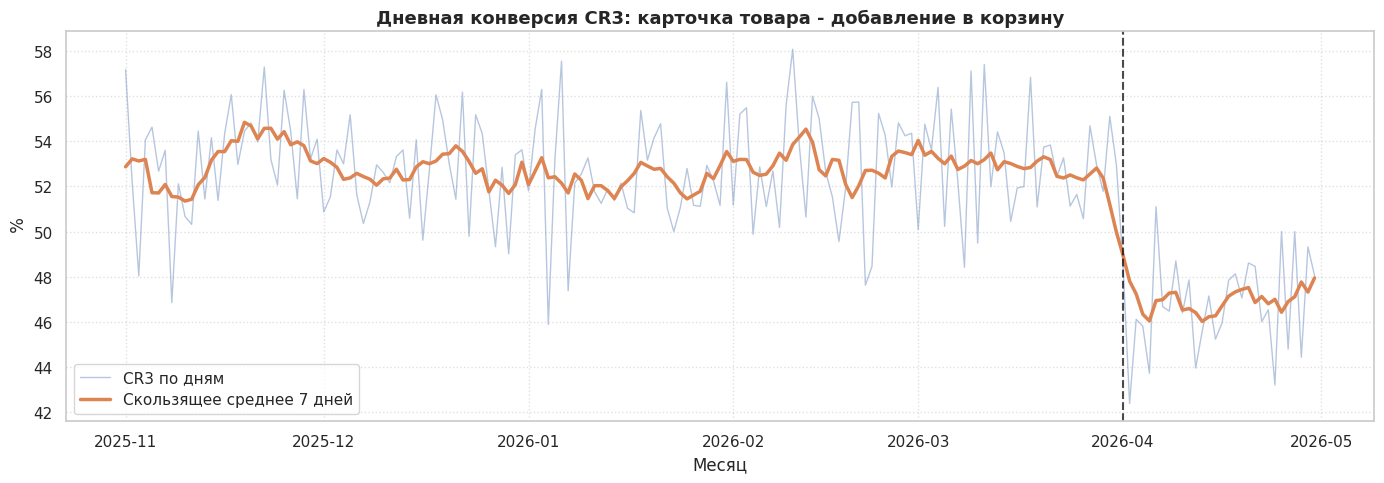

In [415]:
daily_c3 = (
    session
    .groupby("session_date", as_index=False)
    .agg(
        card_view=("product_card_view", "sum"),
        add_to_cart=("add_to_cart", "sum")
    )
)

daily_c3["CR3_view_to_cart"] = (
    daily_c3["add_to_cart"] / daily_c3["card_view"] * 100
).round(2)

daily_c3 = daily_c3.sort_values("session_date")

daily_c3["CR3_rolling_7d"] = (
    daily_c3["CR3_view_to_cart"]
    .rolling(window=7, center=True, min_periods=1)
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_c3["session_date"],
    daily_c3["CR3_view_to_cart"],
    linewidth=1,
    alpha=0.4,
    label="CR3 по дням"
)

plt.plot(
    daily_c3["session_date"],
    daily_c3["CR3_rolling_7d"],
    linewidth=2.5,
    label="Скользящее среднее 7 дней"
)

april_start = pd.Timestamp("2026-04-01")

plt.axvline(
    april_start,
    color="black",
    linestyle="--",
    linewidth=1.5,
    alpha=0.7
)

plt.title(
    "Дневная конверсия CR3: карточка товара - добавление в корзину",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Месяц")
plt.ylabel(" %")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

### Вывод по дневной динамике CR3

График показывает, что до апреля конверсия держалась на относительно стабильном уровне. Были дневные колебания, но скользящее среднее не показывало устойчивого падения.

**Промежуточный вывод:** проблема, вероятно, появилась в начале апреля и связана с изменениями на карточке товара.

In [416]:
months_to_compare = ["2026-03", "2026-04"]

c3_stats = (
    session[session["month"].astype(str).isin(months_to_compare)]
    .groupby("month", observed=False)
    .agg(
        card_view=("product_card_view", "sum"),
        add_to_cart=("add_to_cart", "sum")
    )
)

c3_stats["CR3_percent"] = (
    c3_stats["add_to_cart"] / c3_stats["card_view"] * 100
).round(2)

display(c3_stats)

test_table = [
    [
        c3_stats.loc["2026-03", "add_to_cart"],
        c3_stats.loc["2026-03", "card_view"] - c3_stats.loc["2026-03", "add_to_cart"]
    ],
    [
        c3_stats.loc["2026-04", "add_to_cart"],
        c3_stats.loc["2026-04", "card_view"] - c3_stats.loc["2026-04", "add_to_cart"]
    ]
]

chi2, p_value, dof, expected = chi2_contingency(test_table)

p_march = c3_stats.loc["2026-03", "add_to_cart"] / c3_stats.loc["2026-03", "card_view"]
p_april = c3_stats.loc["2026-04", "add_to_cart"] / c3_stats.loc["2026-04", "card_view"]

n_march = c3_stats.loc["2026-03", "card_view"]
n_april = c3_stats.loc["2026-04", "card_view"]

p_pool = (
    c3_stats.loc["2026-03", "add_to_cart"] +
    c3_stats.loc["2026-04", "add_to_cart"]
) / (n_march + n_april)

se = (p_pool * (1 - p_pool) * (1 / n_march + 1 / n_april)) ** 0.5
z_score = (p_april - p_march) / se

print(f"Разница = {(p_april - p_march) * 100:.2f} п.п.")
print(f"p-value = {p_value:.2e}")
if p_value < 0.05:
    print("Итог: падение CR3 статистически значимо.")
else:
    print("Итог: падение CR3 статистически незначимо.")

,card_view,add_to_cart,CR3_percent
month,,,
2026-03,14972,7916,52.87
2026-04,13815,6460,46.76


Разница = -6.11 п.п.
p-value = 4.24e-25
Итог: падение CR3 статистически значимо.


### Вывод по статистической проверке CR3

Статистический тест подтверждает, что падение конверсии `card_view → add_to_cart` в апреле не похоже на случайное колебание.

**Вывод:** падение C3 статистически значимо. Это подтверждает, что проблема на шаге **карточка товара - добавление в корзину** реальная, а не результат случайного шума в данных.


## Маркетинговые коммуникации
Проверим, могло ли снижение оборота быть связано с маркетинговыми коммуникациями.

## Количество маркетинговых кампаний по месяцам

In [417]:
campaigns_monthly = (
    marketing
    .groupby("month", as_index=False, observed=False)
    .agg(
        campaigns_count=("campaign_id", "nunique")
    )
)

display(campaigns_monthly)

,month,campaigns_count
0,2025-11,10
1,2025-12,11
2,2026-01,10
3,2026-02,9
4,2026-03,11
5,2026-04,10


Далее посмотрим на

1. Сколько пользователей попало в `sent` и `holdout_control`.
2. Сколько сообщений было через `email`, `push` и `in_app`.
3. Как менялась структура маркетинговых коммуникаций.

Этот блок нужен, чтобы понять, был ли в апреле технический сбой или изменение маркетинговой стратегии.


In [418]:
comms_monthly_status = (
    marketing
    .groupby(["month", "send_status"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

comms_monthly_channel = (
    marketing
    .groupby(["month", "communication_type"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

comms_channel_share = (
    comms_monthly_channel
    .set_index("month")
)

comms_channel_share = (
    comms_channel_share
    .div(comms_channel_share.sum(axis=1), axis=0)
    * 100
).round(2).reset_index() 


display(comms_monthly_status)
display(comms_monthly_channel)
display(comms_channel_share)

send_status,month,holdout_control,sent
0,2025-11,5899,5784
1,2025-12,6570,6385
2,2026-01,6153,6153
3,2026-02,5166,5158
4,2026-03,6534,6674
5,2026-04,5920,5797


communication_type,month,email,in_app,push
0,2025-11,7292,2323,2068
1,2025-12,7362,1160,4433
2,2026-01,3785,0,8521
3,2026-02,3812,0,6512
4,2026-03,2190,0,11018
5,2026-04,1227,1191,9299


communication_type,month,email,in_app,push
0,2025-11,62.42,19.88,17.70
1,2025-12,56.83,8.95,34.22
2,2026-01,30.76,0.00,69.24
3,2026-02,36.92,0.00,63.08
4,2026-03,16.58,0.00,83.42
5,2026-04,10.47,10.16,79.36


### Вывод по маркетинговым коммуникациям

Количество отправленных коммуникаций в апреле снизилось относительно марта: с 6674 до 5797, но этот уровень сопоставим с ноябрм (5784). Поэтому резкого провала в доставке сообщений не наблюдается.

Главное изменение видно в структуре каналов коммуникации. В начале периода основным каналом был `email`: в ноябре его доля составляла 62.42%. Далее доля email постепенно снижалась и в апреле стала 10.47%.

При этом доля `push` сильно выросла: с 17.70% в ноябре до 79.36% в апреле.

Также в апреле снова появился канал `in_app` с долей 10.16%, хотя в январе–марте он не использовался.

**Промежуточный вывод:** падение оборота вряд ли связано с полной поломкой маркетинговых отправок, так как объём отправленных не выглядит аномально низким. Но структура каналов заметно изменилась: email почти исчез, а push стал основным каналом. Это могло повлиять на качество маркетингового трафика.


## Эффективность маркетинговых каналов

Посмотрим насколько эффективно каждый канал приводит пользователей к действиям.

> **отправленная коммуникация - сессия - покупка**

Для каждого канала считаем:

* количество кампаний
* количество отправленных сообщений
* количество уникальных получателей
* количество начатых сессий после коммуникации
* количество покупок
* конверсию из получателя в сессию
* конверсию из получателя в покупку
* конверсию из сессии в покупку


In [419]:
sent_marketing = marketing[marketing["send_status"] == "sent"].copy()

funnel_unique = (
    session
    .groupby(["client_id", "campaign_id"], as_index=False, observed=False)
    .agg(
        visited=("service_visit", "max"),
        purchased=("purchase", "max")
    )
)

sent_unique = (
    sent_marketing
    .drop_duplicates(
        subset=[
            "month",
            "communication_type",
            "campaign_id",
            "client_id"
        ]
    )
)

merged_comms = sent_unique.merge(
    funnel_unique,
    on=["client_id", "campaign_id"],
    how="left"
)

merged_comms[["visited", "purchased"]] = (
    merged_comms[["visited", "purchased"]]
    .fillna(0)
)

sent_stats = (
    sent_marketing
    .groupby(["month", "communication_type"], as_index=False, observed=False)
    .agg(
        messages_sent=("communication_id", "count"),
        sent_clients=("client_id", "nunique"),
        campaigns_count=("campaign_id", "nunique")
    )
)

result_stats = (
    merged_comms
    .groupby(["month", "communication_type"], as_index=False, observed=False)
    .agg(
        sessions_started=("visited", "sum"),
        purchases_made=("purchased", "sum")
    )
)

channel_effectiveness = sent_stats.merge(
    result_stats,
    on=["month", "communication_type"],
    how="left"
)

channel_effectiveness[["sessions_started", "purchases_made"]] = (
    channel_effectiveness[["sessions_started", "purchases_made"]]
    .fillna(0)
)

channel_effectiveness["session_cr_percent"] = (
    channel_effectiveness["sessions_started"]
    / channel_effectiveness["sent_clients"]
    * 100
).round(2)

channel_effectiveness["purchase_cr_percent"] = (
    channel_effectiveness["purchases_made"]
    / channel_effectiveness["sent_clients"]
    * 100
).round(2)

channel_effectiveness["session_to_purchase_cr_percent"] = (
    channel_effectiveness["purchases_made"]
    / channel_effectiveness["sessions_started"]
    * 100
).round(2)

channel_effectiveness = (
    channel_effectiveness[
        [
            "month",
            "communication_type",
            "campaigns_count",
            "messages_sent",
            "sent_clients",
            "sessions_started",
            "purchases_made",
            "session_cr_percent",
            "purchase_cr_percent",
            "session_to_purchase_cr_percent"
        ]
    ]
    .sort_values(["communication_type", "month"])
    .reset_index(drop=True)
)

display(channel_effectiveness)

,month,communication_type,campaigns_count,messages_sent,sent_clients,sessions_started,purchases_made,session_cr_percent,purchase_cr_percent,session_to_purchase_cr_percent
0,2025-11,email,6,3660,3074,286.00,55.00,9.30,1.79,19.23
1,2025-12,email,6,3648,3066,294.00,48.00,9.59,1.57,16.33
2,2026-01,email,3,1898,1778,154.00,27.00,8.66,1.52,17.53
3,2026-02,email,3,1933,1813,164.00,33.00,9.05,1.82,20.12
4,2026-03,email,2,1114,1074,94.00,17.00,8.75,1.58,18.09
5,2026-04,email,1,640,640,48.00,7.00,7.50,1.09,14.58
6,2025-11,in_app,2,1111,1074,85.00,11.00,7.91,1.02,12.94
7,2025-12,in_app,1,568,568,58.00,15.00,10.21,2.64,25.86
8,2026-04,in_app,1,606,606,48.00,7.00,7.92,1.16,14.58
9,2025-11,push,2,1013,975,78.00,14.00,8.00,1.44,17.95


### Вывод по эффективности маркетинговых каналов

По таблице видно, что в апреле снизилась эффективность всех основных каналов коммуникации.

У `email` сильно сократился объём. При этом конверсия в сессию снизилась и конверсия в покупку.

Канал `push` остаётся основным по объёму. Однако его эффективность тоже снизилась. 

Канал `in_app` в апреле снова появился после отсутствия в январе–марте.

Также видно, что конверсия из сессии в покупку в апреле снизилась почти по всем каналам. Значит скорей всего проблема не только в маркетинговом привлечении.

**Промежуточный вывод:** маркетинг мог усилить падение, потому что в апреле снизились объёмы и эффективность каналов, особенно email. Но основная проблема всё ещё выглядит продуктовой: пользователи после перехода хуже доходят до покупки.


In [420]:
comms_timing = (
    marketing
    .groupby(["month", "timing_period"], observed=False)
    .size()
    .unstack(fill_value=0)
)

comms_timing_shares = (
    comms_timing
    .div(comms_timing.sum(axis=1), axis=0)
    * 100
)

display(comms_timing_shares.round(2).reset_index())

orders_loss = orders.copy()

orders_loss["marketing_group"] = (
    orders_loss["is_marketing_touched"]
    .map({
        0: "organic",
        1: "mkt_touched",
        0.0: "organic",
        1.0: "mkt_touched",
        "0": "organic",
        "1": "mkt_touched",
        False: "organic",
        True: "mkt_touched"
    })
)

orders_by_marketing = (
    orders_loss
    .groupby(["month", "marketing_group"], observed=False)["order_id"]
    .nunique()
    .unstack(fill_value=0)
)

orders_by_marketing.index = orders_by_marketing.index.astype(str)

delta_org = int(
    orders_by_marketing.loc["2026-04", "organic"]
    - orders_by_marketing.loc["2026-03", "organic"]
)

delta_mkt = int(
    orders_by_marketing.loc["2026-04", "mkt_touched"]
    - orders_by_marketing.loc["2026-03", "mkt_touched"]
)

total_delta = delta_org + delta_mkt

mkt_loss_share = (
    delta_mkt / total_delta * 100
    if total_delta != 0
    else 0
)

print("Потеря заказов март -> апрель:")
print(f" органические: {delta_org}")
print(f" маркетинговые: {delta_mkt}")
print(f" доля маркетинга в общей потере: {mkt_loss_share:.0f}%")

timing_period,month,early_morning,evening
0,2025-11,0.00,100.00
1,2025-12,0.00,100.00
2,2026-01,0.00,100.00
3,2026-02,0.00,100.00
4,2026-03,0.00,100.00
5,2026-04,100.00,0.00


Потеря заказов март -> апрель:
 органические: -790
 маркетинговые: -47
 доля маркетинга в общей потере: 6%


### Вывод по времени отправки и потерям заказов

В апреле время отправки коммуникаций резко изменилось: с ноября по март 100% коммуникаций отправлялись вечером, а в апреле 100% коммуникаций были перенесены на раннее утро.

Это изменение могло повлиять на эффективность маркетинга, но оно не объясняет основную часть падения заказов.

При сравнении марта и апреля видно, что основная потеря пришлась на органические заказы.

**Промежуточный вывод:** изменение времени отправки коммуникаций является потенциальным фактором, но не основной причиной падения оборота. Основная потеря заказов произошла в органике, поэтому ключевая проблема, скорее всего, находится не в маркетинговых рассылках, а в воронке.


### Доставляемость коммуникаций

In [421]:
delivery_attempts = marketing[
    marketing["send_status"].isin(["sent", "failed"])
].copy()

delivery_stats = (
    delivery_attempts
    .groupby(["month", "communication_type"], as_index=False, observed=False)
    .agg(
        attempts=("send_status", "count"),
        delivered=("send_status", lambda x: (x == "sent").sum())
    )
)

delivery_stats["delivery_rate"] = (
    delivery_stats["delivered"] / delivery_stats["attempts"] * 100
).round(2)

delivery_rate_table = (
    delivery_stats
    .pivot(index="month", columns="communication_type", values="delivery_rate")
)

display(delivery_rate_table)

communication_type,email,in_app,push
month,,,
2025-11,100.00,100.00,100.00
2025-12,100.00,100.00,100.00
2026-01,100.00,NaN,100.00
2026-02,100.00,NaN,100.00
2026-03,100.00,NaN,100.00
2026-04,100.00,100.00,100.00


### Интенсивность маркетинговых коммуникаций

In [422]:
sent_marketing = marketing[marketing["send_status"] == "sent"].copy()

intensity_stats = (
    sent_marketing
    .groupby("month", as_index=False, observed=False)
    .agg(
        total_sent=("communication_id", "count"),
        unique_recipients=("client_id", "nunique")
    )
)

intensity_stats["messages_per_client"] = (
    intensity_stats["total_sent"] / intensity_stats["unique_recipients"]
).round(2)

display(intensity_stats)

,month,total_sent,unique_recipients,messages_per_client
0,2025-11,5784,4319,1.34
1,2025-12,6385,4604,1.39
2,2026-01,6153,4517,1.36
3,2026-02,5158,3993,1.29
4,2026-03,6674,4784,1.40
5,2026-04,5797,4343,1.33


Среднее количество сообщений на одного получателя стабильно на протяжении всего периода, примерно 1.3–1.4 сообщения в месяц.

В апреле показатель составил 1.33, что близко к ноябрю и не выглядит аномальным снижением.

In [423]:
monthly_comms = marketing[marketing['send_status'] == 'sent'].groupby('month').agg(
    total_sent_comms=('communication_id', 'count')
).reset_index()

display(monthly_comms)

,month,total_sent_comms
0,2025-11,5784
1,2025-12,6385
2,2026-01,6153
3,2026-02,5158
4,2026-03,6674
5,2026-04,5797


Общее количество успешно отправленных коммуникаций в апреле составило 5797. Это ниже марта, но сопоставимо с ноябрём, поэтому резкого технического провала в объёме отправок не видно.

Падение оборота не объясняется тем, что пользователям резко перестали отправлять коммуникации

In [424]:
stats_summary = []

months = sorted(session["month"].astype(str).unique())

for month in months:
    month_data = session[
        (session["month"].astype(str) == month)
        & (session["experiment_group"].isin(["control", "test"]))
    ].copy()

    if month_data["experiment_group"].nunique() < 2:
        continue

    month_data["purchase_flag"] = month_data["purchase"].astype(int)

    contingency_table = (
        pd.crosstab(
            month_data["experiment_group"],
            month_data["purchase_flag"]
        )
        .reindex(index=["control", "test"], columns=[0, 1], fill_value=0)
    )

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    control_total = contingency_table.loc["control"].sum()
    control_purchases = contingency_table.loc["control", 1]
    control_cr = control_purchases / control_total * 100

    test_total = contingency_table.loc["test"].sum()
    test_purchases = contingency_table.loc["test", 1]
    test_cr = test_purchases / test_total * 100

    lift_pp = test_cr - control_cr

    stats_summary.append({
        "month": month,
        "control_cr_percent": round(control_cr, 2),
        "control_purchases": f"{control_purchases} из {control_total}",
        "test_cr_percent": round(test_cr, 2),
        "test_purchases": f"{test_purchases} из {test_total}",
        "p_value": round(p_value, 6),
        "is_significant": p_value < 0.05
    })

stats_summary_df = pd.DataFrame(stats_summary)

display(stats_summary_df)

,month,control_cr_percent,control_purchases,test_cr_percent,test_purchases,p_value,is_significant
0,2025-11,14.59,81 из 555,16.88,81 из 480,0.36,False
1,2025-12,16.61,106 из 638,17.73,106 из 598,0.66,False
2,2026-01,16.61,95 из 572,17.20,97 из 564,0.85,False
3,2026-02,13.72,62 из 452,17.35,85 из 490,0.15,False
4,2026-03,14.77,92 из 623,14.71,98 из 666,1.00,False
5,2026-04,13.36,70 из 524,13.59,73 из 537,0.98,False


### Вывод по статистической проверке control vs test

По результатам статистических тестов разница между группами `control` и `test` не является статистически значимой ни в одном месяце.

**Промежуточный вывод:** падение оборота и конверсии в апреле нельзя объяснить неудачным A/B-тестом.

## Итоговые выводы и рекомендации

### 1. Ключевой вывод

Падение оборота сервиса в последнем месяце связано прежде всего не со снижением среднего чека, а с ухудшением пользовательской воронки и снижением количества заказов.


При этом количество заказов снизилось с 3955 до 3118  
Средний чек снизился значительно слабее.

Следовательно, основная причина падения оборота - пользователи стали реже доходить до покупки.


### 2. Воронка

Анализ пользовательской воронки показал, что основная просадка произошла на шаге:

**просмотр карточки товара - добавление товара в корзину**

Конверсия этого шага снизилась с 52.87% до 46.76%. Что является статистически значимым изменением (ячейка Вывод по статистической проверке CR3)

Total CR снизился с 15.81% до 13.42%.

Это означает, что пользователи продолжают заходить в сервис и смотреть товары, но заметно реже принимают решение добавить товар в корзину. Поэтому наиболее вероятная зона проблемы - карточка товара, товарное предложение или условия покупки на этапе принятия решения.


Падение наблюдается достаточно широко, поэтому причина, скорее всего, затрагивает общий пользовательский опыт или товарное предложение.


### 3. Маркетинг

Маркетинговые коммуникации могли дополнительно усилить падение.

В данных видно изменение структуры коммуникаций: email-коммуникации почти исчезли, push стал основным каналом, а время отправки сообщений изменилось.

Однако маркетинг не выглядит единственной причиной, так как снижение затронуло не только маркетинговые заказы, но и органические. Поэтому маркетинг - дополнительный фактор.


### 4. Основная гипотеза

Основная гипотеза:

**в апреле ухудшился этап принятия решения о покупке после просмотра карточки товара.**

Возможные причины:

- изменения в дизайне или логике карточки товара
- ухудшение видимости кнопки добавления в корзину
- ошибки при добавлении товара в корзину
- рост цен или ухудшение промо-предложений
- проблемы с наличием товаров
- ухудшение ассортимента
- технические ошибки на карточке товара или в корзине


### 5. Рекомендации

Нужно проверить

1. **Приложение**
   - были ли изменения в карточке товара
   - менялась ли кнопка добавления в корзину
   - менялась ли логика отображения цены, скидок, доставки или наличия товара

2. **Технические ошибки**
   - проблемы загрузки карточек товаров
   - задержки в работе карточки или корзины

3. **Товарное предложение**
   - наличие товаров
   - изменение ассортимента
   - изменение цен
   - изменение скидок и промо
   - изменение условий доставки

4. **Маркетинговые коммуникации**
   - проверить влияние отказа от email
   - сравнить эффективность push и email
   - проверить влияние времени отправки сообщений
   - провести тест возврата прежней структуры коммуникаций


### 6. Финальный вывод

Главная причина падения оборота за последний месяц - снижение количества заказов из-за ухудшения конверсии в пользовательской воронке.

Наиболее проблемный участок - переход от просмотра карточки товара к добавлению товара в корзину.  
Это указывает на проблему в карточке товара, товарном предложении.